# MSE802 Assessment 2 - Task 2: Qiskit Circuits

**Student:** ____________________  
**Course:** MSE802 Quantum Computing  
**Learning outcomes:** LO1 and LO2


## 1. Scope and interpretation of the supplied diagram

The supplied diagram shows H on the upper qubit, X on the lower qubit, followed by a two-input block labelled `C`. In the context of the course material on controlled gates, this notebook interprets `C` as CNOT/CX: upper qubit q0 is the control and lower qubit q1 is the target. This explicit interpretation should be confirmed during peer/tutor review because the assessment diagram is not standard Qiskit notation.

The task has two parts: reproduce the supplied circuit and create an original OpenQASM 2 circuit using multiple qubits and gates. Both circuits are validated locally and executed on Quokka.


In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, qasm2
from qiskit.quantum_info import Statevector

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mse802 import AssessmentConfig, QuokkaClient, run_qasm_locally

config = AssessmentConfig.from_env()
SHOTS = config.shots
SEED = config.seed
RUN_QUOKKA = os.getenv("MSE802_RUN_QUOKKA", "0") == "1"
print(f"shots={SHOTS}, seed={SEED}, Quokka={config.quokka_qasm_url}")


shots=1024, seed=802, Quokka=https://quokka1.quokkacomputing.com/qsim/qasm


## 2. Part A - specified Qiskit circuit

The gates are applied in diagram order: H(q0), X(q1), then CX(q0, q1). A separate state-only circuit is used for exact statevector analysis before measurement is added.


In [2]:
specified_state_circuit = QuantumCircuit(2, name="specified_state")
specified_state_circuit.h(0)
specified_state_circuit.x(1)
specified_state_circuit.cx(0, 1)

specified_circuit = QuantumCircuit(2, 2, name="specified_measured")
specified_circuit.compose(specified_state_circuit, inplace=True)
specified_circuit.measure([0, 1], [0, 1])

print(specified_circuit.draw(output="text"))
operation_names = [instruction.operation.name for instruction in specified_circuit.data]
assert operation_names == ["h", "x", "cx", "measure", "measure"]


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     ├───┤┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ X ├─╫─┤M├
     └───┘└───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


Statevector in Qiskit |q1 q0> order: [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


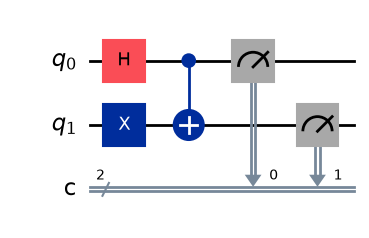

In [3]:
specified_statevector = Statevector.from_instruction(specified_state_circuit)
expected_statevector = np.array([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0], dtype=complex)
assert np.allclose(specified_statevector.data, expected_statevector, atol=1e-8)
print("Statevector in Qiskit |q1 q0> order:", specified_statevector.data)

circuit_figure = specified_circuit.draw(output="mpl", fold=-1)
circuit_figure.savefig("task2_specified_circuit.png", dpi=180, bbox_inches="tight")
display(circuit_figure)


The exact state is $(|01\rangle+|10\rangle)/\sqrt{2}$ in Qiskit's displayed bit order $|q_1q_0\rangle$. Therefore measurement should produce only `01` and `10`, approximately half of the shots each.


## 3. OpenQASM 2 export and local Aer validation


## 4. Part B - original OpenQASM circuit


## 5. Quokka executions and retained evidence


## 6. Results and critical interpretation


## 7. Conclusion


## References

[1] IBM Quantum, "Quantum circuit model," 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/en/guides/circuit-library. [Accessed: 24-Jul-2026].  
[2] IBM Quantum, "OpenQASM 2 module," 2026. [Online]. Available: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qasm2. [Accessed: 24-Jul-2026].  
[3] Quokka Quantum, "Quokka Puck technical specifications," 2026. [Online]. Available: https://www.quokkacomputing.com/product-page/quokka-puck. [Accessed: 24-Jul-2026].
